>> COLUMNS >> MTF50 = 0.0734 cycles/voxel
Detail Size = 13.624 pixels
60
SNR = 11.2539
CNR = 286.9993


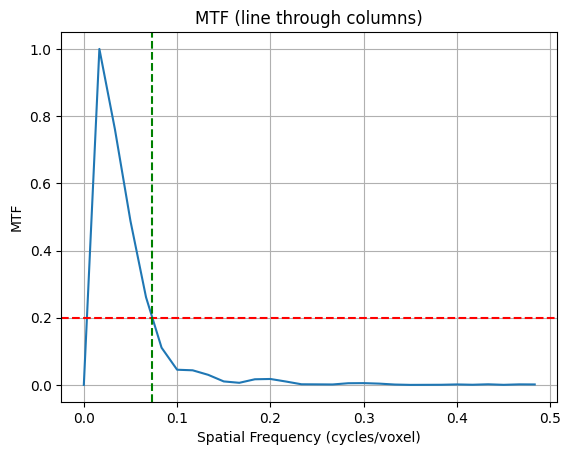

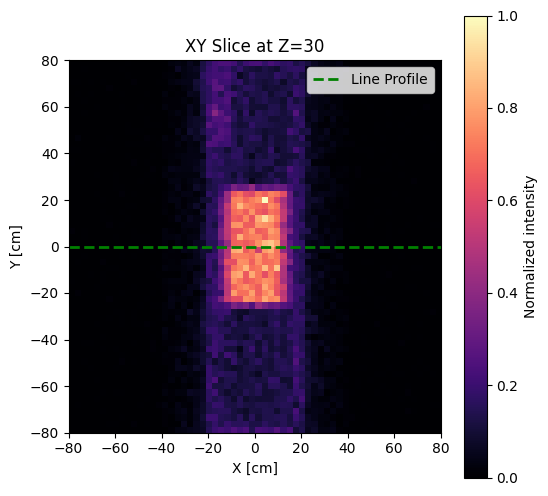

In [ ]:
#         //|                                                    
#        // |                                                    
#       //  |  ||  ______  ||  ______       _______              
#      //   |  || /        || /      \    //       \    ||      /
#     //    |  ||/         ||/        \             |   ||     / 
#    ///////|  ||          ||         |             |   ||    /  
#   //      |  ||          ||         |    _________|   ||   /   
#  //       |  ||          ||         |  //         \   ||  /    
# //        |  ||          ||         |  ||         |   || /     
#//         |  ||          ||         |  \\_________/\  ||/       

import uproot
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
import scipy.ndimage as ndimage
from scipy.signal import savgol_filter

# ==========================================
# CONFIGURATION
# ==========================================
NUM_FILES = 120          # number of projection angles
ANGLE_LIMIT = 60.0       # max rotation +/- 40 deg
VOXEL_RES = 60           # 60x60x60 voxels
BOX_SIZE = 80.0          # object half-size in cm
SIGMA_SMOOTH = 0   # Gaussian smoothing. 0 is with no smoothing, original image
MIN_ANGLE_CUT = 0.5     # minimum scatter angle in deg

# ==========================================
# LOAD DATA AND APPLY POCA (modified)
# ==========================================
def load_data():
    all_x, all_y, all_z, all_w = [], [], [], []

    total_files = 120
    if NUM_FILES > total_files:
        raise ValueError(f"NUM_FILES cannot exceed {total_files}")

    # Compute step to select evenly spaced files
    step = total_files / NUM_FILES
    file_indices = [int(round(i*step)) for i in range(NUM_FILES)]

    angle_step = 2*ANGLE_LIMIT / (total_files-1)
    start_angle = -ANGLE_LIMIT

    for i in file_indices:
        filename = f"output{i}.root"
        rot_angle_deg = start_angle + i*angle_step
        rad = np.radians(-rot_angle_deg)  # inverse rotation to align object

        try:
            with uproot.open(filename) as f:
                data = f["Muons"].arrays(
                    ["poca_x", "poca_y", "poca_z", "angle"],
                    library="np"
                )

                px = data["poca_x"]
                py = data["poca_y"]
                pz = data["poca_z"]
                angles = data["angle"]

                # Filter by scatter angle
                mask = (angles > MIN_ANGLE_CUT) & (angles < 30.0)
                px = px[mask]
                py = py[mask]
                pz = pz[mask]
                angles = angles[mask]

                # Rotate POCA points to align all projections
                cos_rad = np.cos(rad)
                sin_rad = np.sin(rad)

                x_rot = px
                y_rot = py
                z_rot = pz

                all_x.append(x_rot)
                all_y.append(y_rot)
                all_z.append(z_rot)
                all_w.append(angles)

        except (FileNotFoundError, OSError):
            print(f"  [Skipped] {filename}")

    if not all_x:
        raise ValueError("No data loaded!")

    return np.concatenate(all_x), np.concatenate(all_y), np.concatenate(all_z), np.concatenate(all_w)


# ==========================================
# VOXELIZE & SMOOTH
# ==========================================
'''def generate_volume(x, y, z, weights):
    bins = VOXEL_RES
    range_bounds = [[-BOX_SIZE, BOX_SIZE], [-BOX_SIZE, BOX_SIZE], [-BOX_SIZE, BOX_SIZE]]

    hist_signal, edges = np.histogramdd((x, y, z), bins=bins, range=range_bounds, weights=weights)
    hist_counts, _ = np.histogramdd((x, y, z), bins=bins, range=range_bounds)

    with np.errstate(divide='ignore', invalid='ignore'):
        volume = hist_signal / hist_counts
        volume[hist_counts == 0] = 0

    volume_smooth = ndimage.gaussian_filter(volume, sigma=SIGMA_SMOOTH)
    return volume_smooth, edges'''

def generate_volume(x, y, z, weights):
    bins = VOXEL_RES
    range_bounds = [[-BOX_SIZE, BOX_SIZE],
                    [-BOX_SIZE, BOX_SIZE],
                    [-BOX_SIZE, BOX_SIZE]]

    # Only use counts
    hist_counts, edges = np.histogramdd((x, y, z),
                                        bins=bins,
                                        range=range_bounds)

    # Apply smoothing to fill interior
    volume = ndimage.gaussian_filter(hist_counts, sigma=SIGMA_SMOOTH)

    # Normalize the entire volume to 0-1
    volume = (volume - np.min(volume)) / (np.max(volume) - np.min(volume))

    return volume, edges


# ==========================================
# INTERACTIVE SLICE VIEWER
# ==========================================
class SliceViewer:
    def __init__(self, volume, edges):
        self.volume = volume
        self.edges = edges
        self.res = volume.shape[0]
        self.ind_x = self.res//2
        self.ind_y = self.res//2
        self.ind_z = self.res//2

        self.fig, self.ax = plt.subplots(2,2,figsize=(12,10))
        plt.subplots_adjust(bottom=0.25)

        self.ax[0,0].set_title("XY Slice")
        self.ax[0,1].set_title("YZ Slice")
        self.ax[1,0].set_title("XZ Slice")
        self.ax[1,1].axis('off')
        self.ax[1,1].text(0.1,0.5,"Controls\nUse sliders", fontsize=12)

        extent = [-BOX_SIZE, BOX_SIZE, -BOX_SIZE, BOX_SIZE]
        cmap='magma'

        self.im_xy = self.ax[0,0].imshow(self.volume[:,:,self.ind_z].T, origin='lower', extent=extent, cmap=cmap)
        self.im_yz = self.ax[0,1].imshow(self.volume[self.ind_x,:,:].T, origin='lower', extent=extent, cmap=cmap)
        self.im_xz = self.ax[1,0].imshow(self.volume[:,self.ind_y,:].T, origin='lower', extent=extent, cmap=cmap)

        self.fig.colorbar(self.im_xy, ax=self.ax[0,0])
        self.fig.colorbar(self.im_yz, ax=self.ax[0,1])
        self.fig.colorbar(self.im_xz, ax=self.ax[1,0])

        axcolor='lightgoldenrodyellow'
        self.s_z = Slider(plt.axes([0.2,0.15,0.6,0.03], facecolor=axcolor), 'Z-Slice', 0, self.res-1, valinit=self.ind_z, valstep=1)
        self.s_x = Slider(plt.axes([0.2,0.10,0.6,0.03], facecolor=axcolor), 'X-Slice', 0, self.res-1, valinit=self.ind_x, valstep=1)
        self.s_y = Slider(plt.axes([0.2,0.05,0.6,0.03], facecolor=axcolor), 'Y-Slice', 0, self.res-1, valinit=self.ind_y, valstep=1)

        self.s_z.on_changed(self.update)
        self.s_x.on_changed(self.update)
        self.s_y.on_changed(self.update)

        ax_but = plt.axes([0.8,0.05,0.1,0.04])
        self.b_3d = Button(ax_but,'Show 3D', color=axcolor, hovercolor='0.975')
        self.b_3d.on_clicked(self.show_3d)

    def update(self,val):
        self.ind_z = int(self.s_z.val)
        self.ind_x = int(self.s_x.val)
        self.ind_y = int(self.s_y.val)

        self.im_xy.set_data(self.volume[:,:,self.ind_z].T)
        self.im_yz.set_data(self.volume[self.ind_x,:,:].T)
        self.im_xz.set_data(self.volume[:,self.ind_y,:].T)
        self.fig.canvas.draw_idle()

    def show_3d(self,event):
        fig3d = plt.figure(figsize=(10,10))
        ax = fig3d.add_subplot(111, projection='3d')
        threshold = np.percentile(self.volume,95)
        voxels = self.volume > threshold
        colors = plt.cm.magma(self.volume)
        colors[...,3] = (self.volume / np.max(self.volume))**2
        ax.voxels(voxels, facecolors=colors, edgecolors=None, shade=True)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f'3D Reconstruction (Threshold > {threshold:.2f})')
        plt.show()

# ==========================================
# MAIN
# ==========================================
if __name__ == "__main__":
    x, y, z, w = load_data()
    volume, edges = generate_volume(x, y, z, w)
    #print("Launching interactive viewer...")
    #viewer = SliceViewer(volume, edges)
    #plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from numpy.fft import fft, fftfreq, fftshift


# ========================================================
# ----------------------- MTF ----------------------------
# ========================================================

# Extract one line (row 30, all columns, slice 30)

'''
LINE PROFILE ALONG COLUMNS
'''

line_profile = volume[:, 30, 30]

line_profile = line_profile - np.mean(line_profile)  # normalize around zero
line_profile = savgol_filter(line_profile, window_length=11, polyorder=3)

# FFT → MTF
N = len(line_profile)
mtf = np.abs(fft(line_profile))
mtf = mtf / np.max(mtf)

# Spatial frequencies
dx = 1  # voxel size
freqs = fftfreq(N, d=dx)
freqs = fftshift(freqs)
mtf = fftshift(mtf)

# Only positive frequencies
positive_freqs = freqs[freqs >= 0]
positive_mtf = mtf[freqs >= 0]

# Interpolate MTF50
interp_func = interp1d(positive_mtf, positive_freqs, fill_value='extrapolate')
mtf50 = interp_func(0.2)
mtf50 = round(float(mtf50), 4)

ds = 1 / mtf50
ds = round(float(ds), 4)

print(">> COLUMNS >> MTF50 =", mtf50, "cycles/voxel")
print("Detail Size = " + str(ds) + " pixels")

# Plot
plt.plot(positive_freqs, positive_mtf)
plt.axhline(0.2, color='r', linestyle='--')
plt.axvline(mtf50, color='g', linestyle='--')
plt.title("MTF (line through columns)")
plt.xlabel("Spatial Frequency (cycles/voxel)")
plt.ylabel("MTF")
plt.grid(True)
#plt.show()

# Middle slice index (or Z=30)
ind_z = 30
slice_xy = volume[:, :, ind_z]

# Plot the 2D slice
plt.figure(figsize=(6,6))
plt.imshow(slice_xy.T, origin='lower', extent=[-BOX_SIZE, BOX_SIZE, -BOX_SIZE, BOX_SIZE], cmap='magma')
plt.colorbar(label="Normalized intensity")
plt.title(f"XY Slice at Z={ind_z}")

# Overlay the line where line profile was taken (row 30)
# Convert voxel index to physical coordinates
voxel_size = 2 * BOX_SIZE / volume.shape[0]
y_phys = -BOX_SIZE + 30 * voxel_size  # row index = 30
plt.axhline(y=y_phys, color='g', linestyle='--', linewidth=2, label="Line Profile")

plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
plt.legend()
#plt.show()


# ========================================================
# ----------------------- SNR ----------------------------
# ========================================================
# SNR = mean(signal) / std(noise)

# Choose signal and background ROIs  
# (you MUST set these based on your reconstructed volume!)

# Example ROIs ----------
signal_roi = volume[29:31, 29:31, 29:31]      # inside object
background_roi = volume[0:3, 29:31, 29:31]  # empty region

signal_mean = np.mean(signal_roi)
noise_std = np.std(signal_roi)

print(len(volume))

snr = signal_mean / noise_std
snr = round(float(snr), 4)
print("SNR =", snr)


# ========================================================
# ----------------------- CNR ----------------------------
# ========================================================
# CNR = |mean(signal) - mean(background)| / noise_std

background_mean = np.mean(background_roi)
background_std = np.std(background_roi)
cnr = np.abs(signal_mean - background_mean) / background_std
cnr = round(float(cnr), 4)
print("CNR =", cnr)


